# Warehouse location and fleet forecasting

Workflow:
1. Extract data from the file with options
2. Plot a delivery point graph
3. Divide the delivery point into clusters (number of vehicles). Justify the choice of the number of vehicles
4. Analyze the initial partitioning into clusters in terms of vehicle capacity utilization
5. If necessary, exchange nodes between clusters and/or create new clusters
6. Analyze the result of the new partitioning
7. Solve traveling salesman problems for each cluster using a genetic algorithm
8. Analyze the resulting routes
9. Analyze transport utilization characteristics

## 1. Import libraries and data

In [14]:
import pandas as pd
from pandas import read_csv
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from math import ceil


In [7]:
data = read_csv('Retail_stores.csv', header = 0, index_col= 0)

## 2. Acquaintance with data

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       200 non-null    float64
 1   Y       200 non-null    float64
 2   Demand  0 non-null      float64
 3   demand  200 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


In [9]:
del data['Demand']
data

,X,Y,demand
0,-10.564807,-8.261978,223
1,-14.391704,16.716745,337
2,1.675834,3.174182,216
3,11.187684,11.774094,97
4,6.833063,10.857710,351
...,...,...,...
195,-17.998140,14.449818,358
196,12.160333,4.299443,375
197,-13.561926,-6.276303,52
198,2.735801,-4.310057,251


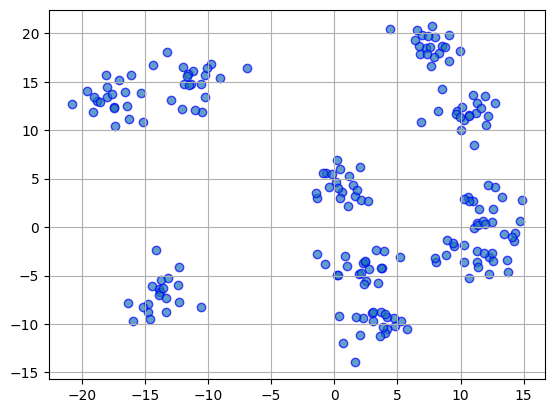

In [26]:
plt.scatter(data.iloc[:,0], data.iloc[:,1], alpha=0.7, edgecolors='b')
plt.grid(True)
plt.show()

## 3. Clustering and Logistics Calculations

Calculate the number of required clusters (1 cluster: 1 truck): the demand of all stores for the carrying capacity of one truck.

Capacity of a truck is 3000kg

In [27]:
capacity = 3000
n_truck = ceil(sum(data.iloc[:, -1]) / capacity)
print('Due to the demand and the capacity of a truck the number of required clusters is', n_truck)

Due to the demand and the capacity of a truck the number of required clusters is 17


In [ ]:
# distribute points into clusters
kmeans_model = KMeans(n_clusters = n_truck)
kmeans = kmeans_model.fit(data.iloc[:, 0:2])

In [32]:
# add № cluster in the dataframe
df_data = data.copy()
df_data['Cluster'] = kmeans.labels_ + 1 

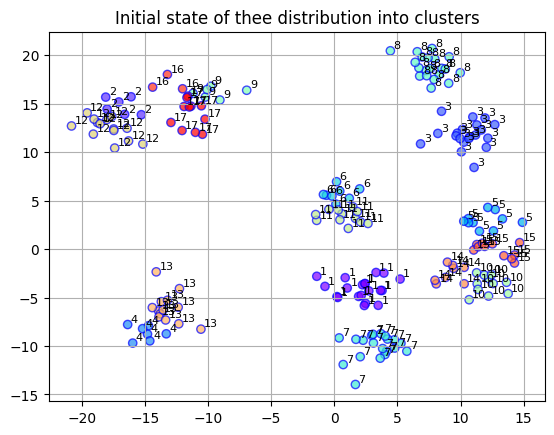

In [33]:
xes=list(df_data.iloc[:,0])
yes=list(df_data.iloc[:,1])
labels = list(df_data.iloc[:,-1])

plt.scatter(xes, yes, c = labels, cmap = 'rainbow', alpha = 0.7, edgecolors = 'b')
for i, txt in enumerate(labels):
    plt.annotate(txt, (xes[i] + 0.25, yes[i] + 0.25), fontsize = 8)

plt.title('Initial state of thee distribution into clusters')
plt.grid(True)
plt.show()

With this distribution, the carrying capacity of each of the 17 trucks will be:

In [34]:
cap_after = []

for i in range(1, max(df_data['Cluster']) + 1):
    current_truck = df_data.loc[df_data['Cluster']==i]
    cap_dif = capacity - sum(current_truck['demand'].values)
    cap_after.append(cap_dif)

print(pd.DataFrame(data=cap_after, columns=['Left capacity'], index = list(range(1, max(df_data['Cluster']) + 1))))


    Left capacity
1           -1844
2            1482
3           -1828
4            1634
5             324
6            1218
7            -860
8           -2701
9            1789
10            509
11             -7
12           -441
13           -478
14           1119
15            372
16           2499
17            107


Looking at the initial clustering of points, the segmentation appears to be reasonably successful, as no clear outliers have emerged.

However, the table representing vehicle capacity utilization indicates negative results: some clusters require more transport capacity than is currently available.

## 4. Constraint Handling via Cluster Reassignment and Hub Formation

To address the emerging issue, introduce the concept of delivery zones, referred to as 'hubs', and assign existing clusters to these hubs. Redistribution of points is allowed only within the boundaries of a given hub.

If a hub can no longer accommodate clusters that satisfy the demand constraints of assigned points, a new cluster is created to ensure feasibility.

The introduction of such hubs is particularly useful in scenarios involving the opening of new warehouses or when considering a transition to vehicles with higher load capacity.

### 4.1. Functions for sorting list elements

### 4.2. Preparation of data 

In [35]:
hubs = [[2, 9, 12, 16, 17], [4, 13], [1, 7], [6, 11], [3, 8], [5, 10, 14, 15]] 

In [41]:
# add a column with hubs
df_data['Hub'] = None

for i in range(len(hubs)):
    for j in hubs[i]:
        df_data.loc[df_data['Cluster'] == j, 'Hub'] = i + 1

df_data

,X,Y,demand,Cluster,Hub
0,-10.564807,-8.261978,223,13,2
1,-14.391704,16.716745,337,16,1
2,1.675834,3.174182,216,11,4
3,11.187684,11.774094,97,3,5
4,6.833063,10.857710,351,3,5
...,...,...,...,...,...
195,-17.998140,14.449818,358,2,1
196,12.160333,4.299443,375,5,6
197,-13.561926,-6.276303,52,13,2
198,2.735801,-4.310057,251,1,3


In [42]:
# the table for calculation of new load capacity utilization
df_left_cap = pd.DataFrame(data = None, columns=['Left capacity'], index = list(range(1, n_truck + 1)))

### 4.3.